In [1]:
import pandas as pd
import ast
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import seaborn as sns
import numpy as np
from scipy.stats import norm

In [2]:
data_file_path = "../../data/cleaned_t2dm_a2h_hba1c.xlsx"
t2dm_a2h = pd.read_excel(data_file_path,
                         sheet_name='T2DM_A2H_HBA1C',
                         dtype=str,
                         keep_default_na=False,
                         engine="openpyxl")
preclinical_trial_arms = pd.read_excel(data_file_path,
                         sheet_name='preclinical_trial_arms',
                         dtype=str,
                         keep_default_na=False,
                         engine="openpyxl")
clinical_trial_arms = pd.read_excel(data_file_path,
                         sheet_name='clinical_trial_arms',
                         dtype=str,
                         keep_default_na=False,
                         engine="openpyxl")

In [ ]:
def plot_one_dist(data,
                  title,
                  hist_color='green',
                  line_color='red',
                  bin_n=50):
    sns.set_theme(style='whitegrid')

    data = [float(d) for d in data]
    
    g = sns.histplot(
        data,
        color=hist_color,
        alpha=0.5,
        bins=bin_n,
    )
    g.set(
        xlabel='Change of HbA1c Value (%)',
        ylabel='Count',
    )

    g2 = plt.twinx()
    sns.kdeplot(
        data,
        color=line_color,
        linestyle='--',
        legend=False,
        ax=g2,
    )
    g2.set(
        ylabel='Density',
    )
    plt.title(title)
    plt.show()

def plot_combined_dist(preclinical_data, clinical_data):
    preclinical_data = [float(d) for d in preclinical_data]
    clinical_data = [float(d) for d in clinical_data]
    sns.set_theme(style='whitegrid')
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Histogram on primary y-axis
    sns.histplot(preclinical_data, bins=50, color='blue', alpha=0.4, label='Preclinical Trials', ax=ax1, stat='count')
    sns.histplot(clinical_data, bins=50, color='green', alpha=0.4, label='Clinical Trials', ax=ax1, stat='count')

    # KDE on secondary y-axis
    ax2 = ax1.twinx()
    sns.kdeplot(preclinical_data, color='blue', linestyle='--', ax=ax2)
    sns.kdeplot(clinical_data, color='green', linestyle='--', ax=ax2)

    ax2.set_ylabel('Density')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    ax1.set_xlabel('Change of HbA1c Value (%)')
    plt.title('Preclinical Trials & Clinical Trials Outcome Measure')
    plt.tight_layout()
    plt.show()
    

def plot_delta_dist(delta_data, bin_n=50):

    # Plot histogram and density
    fig, ax1 = plt.subplots(figsize=(8, 5))
    sns.histplot(delta_data, bins=bin_n, ax=ax1, color='skyblue')
    # ax1.set_xlabel("Change")
    ax1.set_ylabel("Count")

    # Create secondary y-axis for density
    ax2 = ax1.twinx()
    kde_line = sns.kdeplot(delta_data, color='red', ax=ax2, linestyle='-')
    ax2.set_ylabel("Density")

    # Get KDE x and y data
    x_vals = kde_line.lines[0].get_xdata()
    y_vals = kde_line.lines[0].get_ydata()

    # Interpolate to get KDE height at specific x positions (mu, mu±0.5σ)
    from numpy import interp
    sigma = np.array(delta_data).std()
    targets = [-0.5 * sigma, 0.5 * sigma]
    colors = ['red', 'red']
    labels = ['μ - 0.5σ', 'μ + 0.5σ']

    for x, c, label in zip(targets, colors, labels):
        y = interp(x, x_vals, y_vals)  # Linear interpolation
        ax2.plot([x, x], [0, y], color=c, linestyle=':', linewidth=2, label=label)


    plt.title(f'T2DM Preclinical to Clinical δ')
    # plt.tight_layout()
    plt.tight_layout(pad=2.0)  # Increase padding between elements
    plt.savefig("t2dm_plot.png", dpi=800, bbox_inches='tight')
    plt.show()

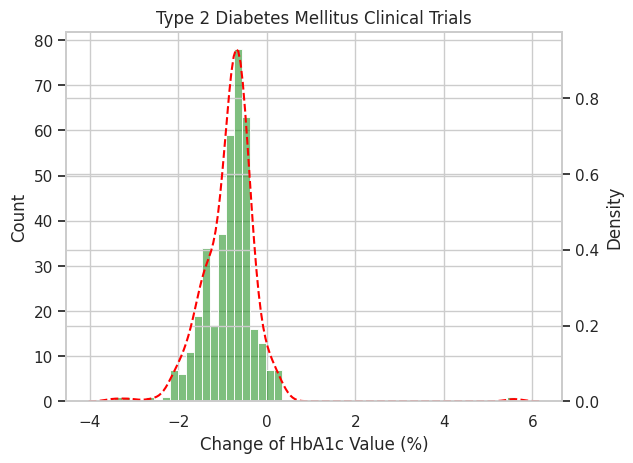

In [4]:
clinical_data = clinical_trial_arms["clinical_change_of_hba1c_value"].to_list()
plot_one_dist(clinical_data, "Type 2 Diabetes Mellitus Clinical Trials",
                  hist_color='green',
                  line_color='red')

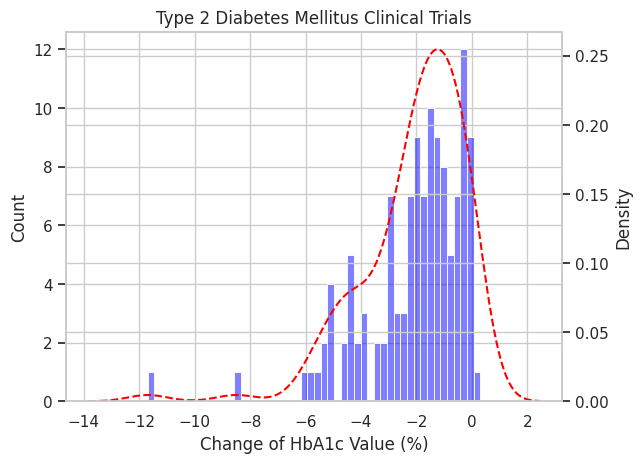

In [5]:
preclinical_data = preclinical_trial_arms["preclinical_change_of_hba1c_value"].to_list()
plot_one_dist(preclinical_data, "Type 2 Diabetes Mellitus Clinical Trials",
                  hist_color='blue',
                  line_color='red')

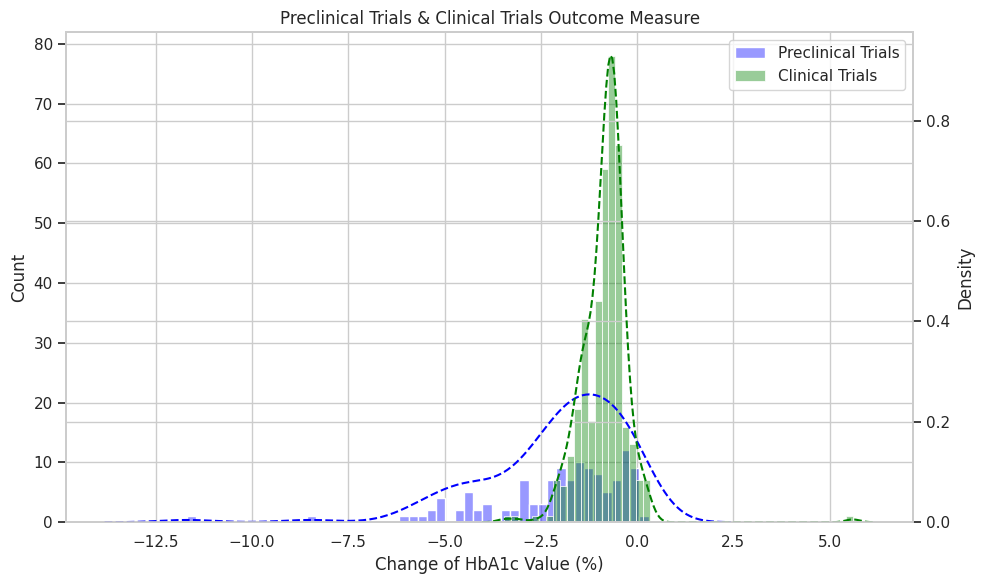

In [6]:
plot_combined_dist(preclinical_data,
                   clinical_data)

In [7]:
t2dm_a2h.columns

Index(['pmcid', 'link', 'preclinical_year',
       'preclinical_change_of_hba1c_value', 'preclinical_treatment_name',
       'preclinical_dosage_amount_value', 'preclinical_dosage_amount_unit',
       'preclinical_administration_route', 'animal_strain', 'animal_species',
       'animal_sex', 'animal_subject_size', 'disease_induction_method',
       'animal_weight_value(g)', 'animal_age(days)',
       'preclinical_dosage_frequency', 'preclinical_dosage_duration(days)',
       'preclinical_total_doses', 'NCT Number', 'age_groups', 'gender',
       'phases', 'sample_size', 'clinical_treatment_name',
       'clinical_change_of_hba1c_value', 'clinical_dosage_amount(mg)',
       'clinical_dosage_frequency', 'clinical_dosage_duration(days)',
       'clinical_total_doses', 'clinical_total_dosage(mg)', 'result',
       'result_translation_success'],
      dtype='object')

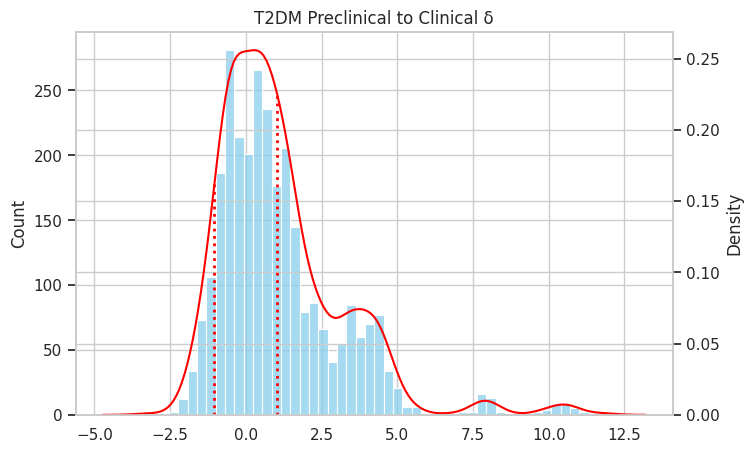

In [8]:
t2dm_a2h['delta'] = t2dm_a2h.apply(lambda x:
        float(x['clinical_change_of_hba1c_value']) - float(x["preclinical_change_of_hba1c_value"]), axis=1
    )
plot_delta_dist(t2dm_a2h['delta'].to_list())